# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [1]:
!pip install langdetect

In [2]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


***

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [4]:
# datos = pd.read_csv('/content/drive/MyDrive/Ciencia de Datos/7. Modelo Hackathon/datos/IMDB Dataset SPANISH.csv')
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/Data-Science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [5]:
datos = datos[['review_es', 'sentimiento']]

In [6]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [7]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [8]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [9]:
datos.sample(10)

,review_es,sentimiento
8068,"Por favor, no me odies, pero tengo que ser hon...",negativo
44056,Esta característica totalmente extraña de bola...,positivo
17648,"Ante el miedo, pero sobre todo en el sentido q...",negativo
15825,Esta película es una adaptación bastante justa...,positivo
4597,Tal vez sea solo porque tengo un miedo intenso...,positivo
17578,"El padre del baterista alcohólico de la OMS, K...",positivo
11212,My friends and I were just discussing how frus...,positivo
9155,Amo la bota das.Esperaba algo en líneas simila...,negativo
39774,"Tan malo como esta película es, me gusta mucho...",negativo
2517,Vi esta película de 1997 porque soy fan de Lor...,positivo


### **Verificación de Dimensiones y Tipos**

In [10]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [12]:
datos.shape

(50000, 2)

In [13]:
datos = datos.drop_duplicates()

In [14]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [15]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Nadie espera que las películas de Star Trek se...,positivo
freq,1,24886


In [16]:
datos['review_es'].describe()

,review_es
count,49599
unique,49599
top,Nadie espera que las películas de Star Trek se...
freq,1


In [17]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

,n_palabras
0,345
1,161
2,173
3,137
4,237
...,...
49995,170
49996,105
49997,246
49998,232


In [18]:
datos['n_palabras'].describe()

,n_palabras
count,49599.000000
mean,237.436884
std,179.696966
min,6.000000
25%,124.000000
50%,173.000000
75%,293.000000
max,2450.000000


#### Longitud extrema: análisis más profundo de outliers

In [19]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

,n_palabras
0.90,474.0
0.95,623.0
0.99,913.0


In [20]:
pd.set_option('display.max_colwidth', None)

In [21]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

31658    I did not know for some time in my youth all that could in general be known about this film however the ways of making a film was not what in fact drew my attention, what made this motion picture one the most liked films even to this very day that I have ever seen was of the Heroism,bravery and the Honor to have served in Her Majestys ServiceThis film is not always what it seems and that is perhaps as it should be,however I cant say enough for the courage exhibited by SgtCutter in defense of The Uniform that he too would of sacrificed his life to save from peril of the sort that they and the troop were threatened with the emergence of this thugee groupTo be certain Sgt Cutter is the kind of individual you might suggest something about and then you watch this unequivocal belief not only in each other but in her Majesty the Queen of EnglandI think for all of his lust for money and the such that that character was greatA reckless brave courageous soldier who did not know fearI think Grant was excellent in this role,truly a very capable rendering made compelling by the uniform that he woreI never felt Ballantine was a shoe-in ,in fact there was so much confidence in there assumptions that you might be well not to look to close because it is still only a pictureWhat do I mean?This picture is still only a motion picture and like the times in which these events take place as well as when the picture was actually made provide a look at how things were done then and what or why there are so many different opinions as to this motion picture will distract your attentionBoth Ballantine and MaChesney are equal in there dedication with both men from time to time providing a unflinching daring as to there jobs as men in the service of Her MajestyThese three seem to bring things off rather well and I believe it is a useful,even enjoyable interlude when Ballantine has a date with destiny or so it would seem only to have fate as you would have it interveneIs it Believable?I don't knowI think it is very fitting when the company having escaped the clutches of death in Tantrapur and they are dragging there tails as they are approaching the main gates to the Regiments Post when Ballantine allows the other two to know that he is leaving the service,and getting married and going into the tea businessMaChesney says he could sign up for another 9 yearsIt will make a man out of himI like that sentimentI don't think there is any doubt as to just what it means to have brave dependable courageous soldiers representing your very best interestsWhere does this end,in fact it may never endThose interests are so well placed as to what is important in this world that I enjoy this picture today as much as perhaps I enjoyed the picture when I was ten years oldI had never known about the truthfulness of this film up to recently when I went into history and found the information about KaliThere is quite a good deal to learn however once all is said and done about the historical significance of the Goddess of Kali,this motion picture takes on a quality that I refer to as intelligenceThis is a very honest attempt to convey a belief in what is being attemptedI think this is an excellent filmGeorge Stevens directedThere is a few items to be aware of I don't think all the information will jive with history however when the Journalist is addressed as MrKipling things can get very emotional because all the rest are characters but this is Rudyard Kipling?George Stevens went over the top to convey a time and a time before when these events actually occurredThe information is honest,compelling and it will not only draw you in but you will need to understand about why we so love Gunga DinThere is in the distance the Black Watch is out in front and they are approaching a most certain peril and possible defeat unless the troop can be warnedSgtCutter is seriously wounded and Ballantine as well as MaChesney are restrainedDin having a deep wound at the base of his back as 

In [22]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
29243                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                La verdadera historia de un parapléjico español, Ramón Sampedro, que luchó durante décadas por el derecho a ser eutenizado. Esta película, junto con el mejor ganador de la imagen del mismo año, un millón de dólares, causó un revuelo ese año con sus representaciones de personas con discapacidad que desean la muerte. Ambos defensores para los discapacitados y (desafortunadamente para los defensores de la discapacidad) Los grupos conservadores pro-vida protestaron con ambas películas y sus nominaciones de Oscar. Las nominaciones también llegaron durante toda la debacle de Terry Schiavo, solo para ponerlo todo en alguna perspectiva histórica. Las protestas, especialmente de los grupos de discapacidad, contra el bebé de un millón de dólares, tienen algún sentido, la película claramente representada, sin vacilar, la vida de un parapléjico como sin valor. El carácter central de la película, Maggie Fitzgerald, se convierte en parapléjico, no parece obtener ningún consejo, sin ayuda, sin ayuda, e inmediatamente quiere morir. La película es, honestamente, bastante tonta y sin compromiso. El mar interior, basado en la historia real, es ciertamente mucho más reflexivo sobre el tema. Lo más probable es que tuviera un ferrocarril en la misma categoría que los millones de dólares, sin que sus manifestantes lo hayan visto, un fenómeno increíblemente común. La película da tiempo a muchos lados diferentes del argumento. Y inmediatamente declara que el deseo de morir es el de los protagonistas y el protagonista solo. Sin embargo, es culpable de un par de delitos, y todavía entendía por qué los grupos de discapacidad podrían tener un problema con él. En primer lugar, existe la reunión del protagonista con un obispo parapléjico. No veo amablemente en la forma en que está representada. Su silla de ruedas operada por vía oral se muestra como absurda, y hay casi una secuencia cómica donde su afeminado, los sirvientes de juguete para niños lo están arrastrando, en su silla, subiendo las escaleras. Ni siquiera puede llegar a la habitación en la que se encuentra Ramón, y uno de los juguetes, se ve obligado a llevar la conversación entre ellos. Tuve que pensar, Gee, tal vez si Ramón vivía en un hogar un poco más accesible para sillas de ruedas, no pasaría toda su vida en la cama, y ​​podría encontrar la vida más satisfactoria (quienes saben cuán de cerca la película r

In [23]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [24]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,24886
negativo,24713


In [25]:
datos['sentimiento'].value_counts(normalize=True)

,proportion
sentimiento,
positivo,0.501744
negativo,0.498256


In [26]:
datos.sample(10)

,review_es,sentimiento,n_palabras
4992,Primero vi esta película cuando era un estudia...,positivo,169
13951,"Weird.Este es una película de TV, pero la cali...",negativo,160
40500,Capt. Gallagher (Lemmon) y alojador de vuelo E...,negativo,271
14400,La caída del mercado de valores de 1929 y la d...,positivo,461
1432,Este tipo de parcela realmente tiene mucho pot...,negativo,171
18589,Esta divertida dibujos animados de Bugs Bunny ...,positivo,232
43509,Tu PA TAM es una de las peores películas que h...,negativo,203
30489,Realmente me gustó esta película ... pero los ...,positivo,500
43325,Este juego fue terrible. Creo que trabajaron d...,negativo,433
17173,La peor película que he visto en los últimos 1...,negativo,124


### **Graficos**

In [27]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [28]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [29]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

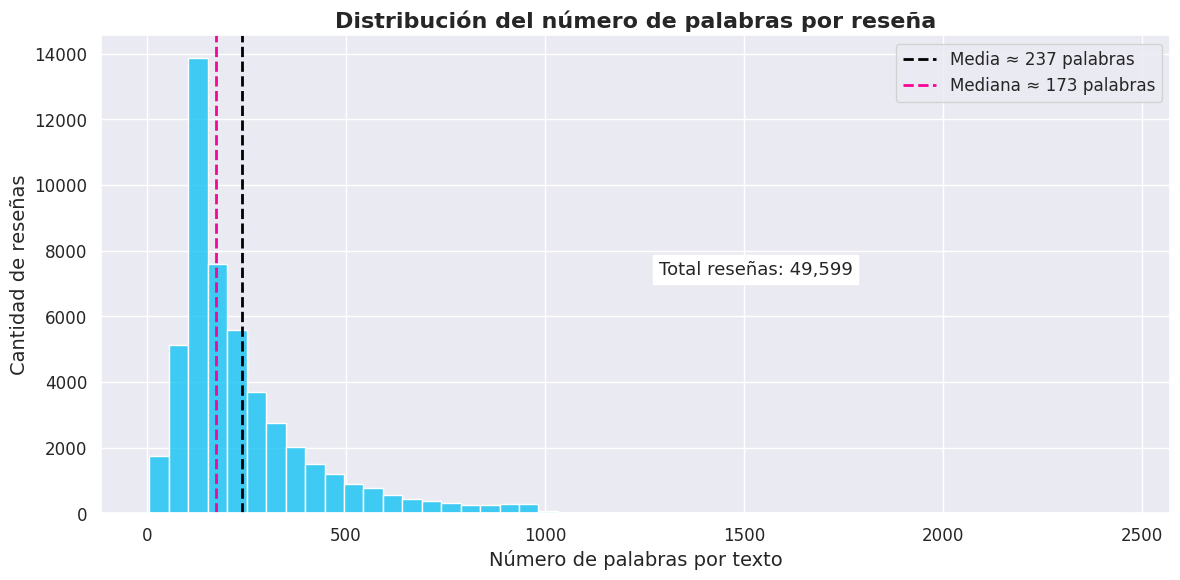

In [30]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

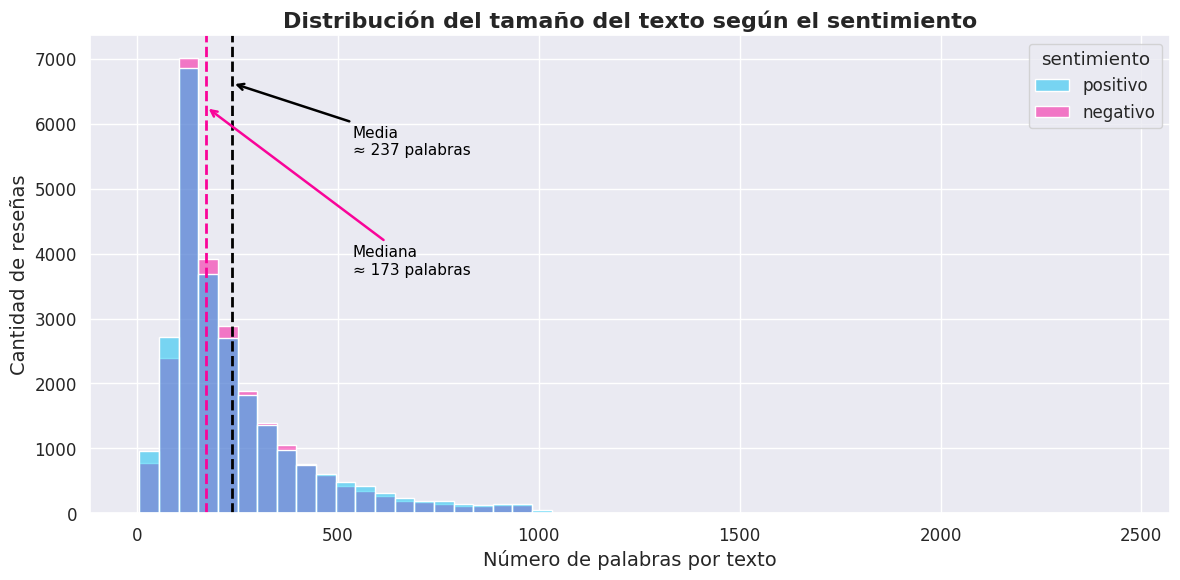

In [31]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

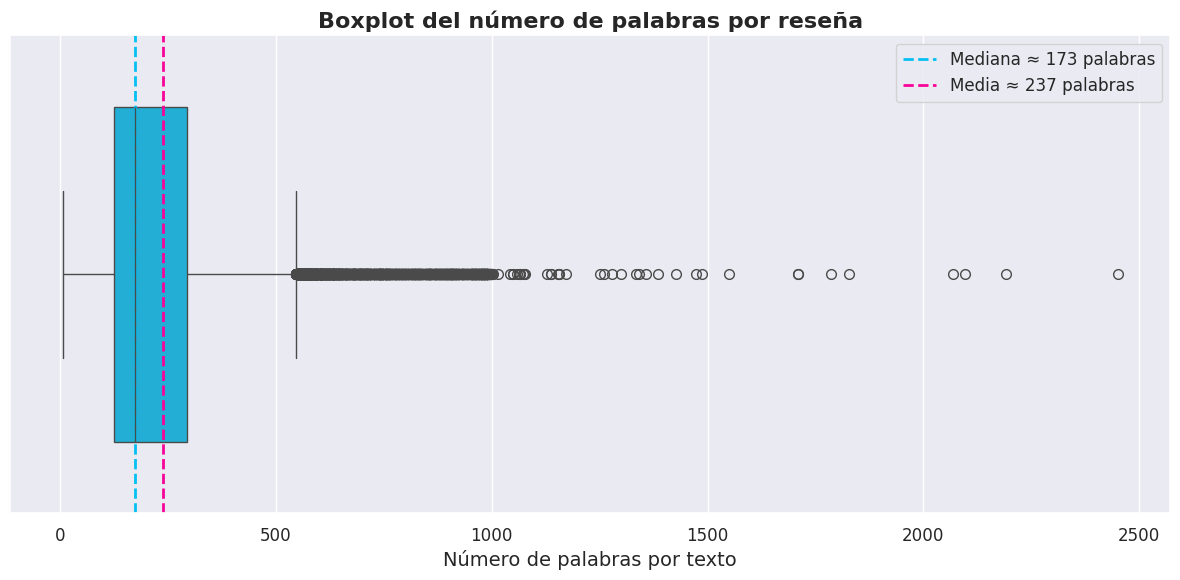

In [32]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

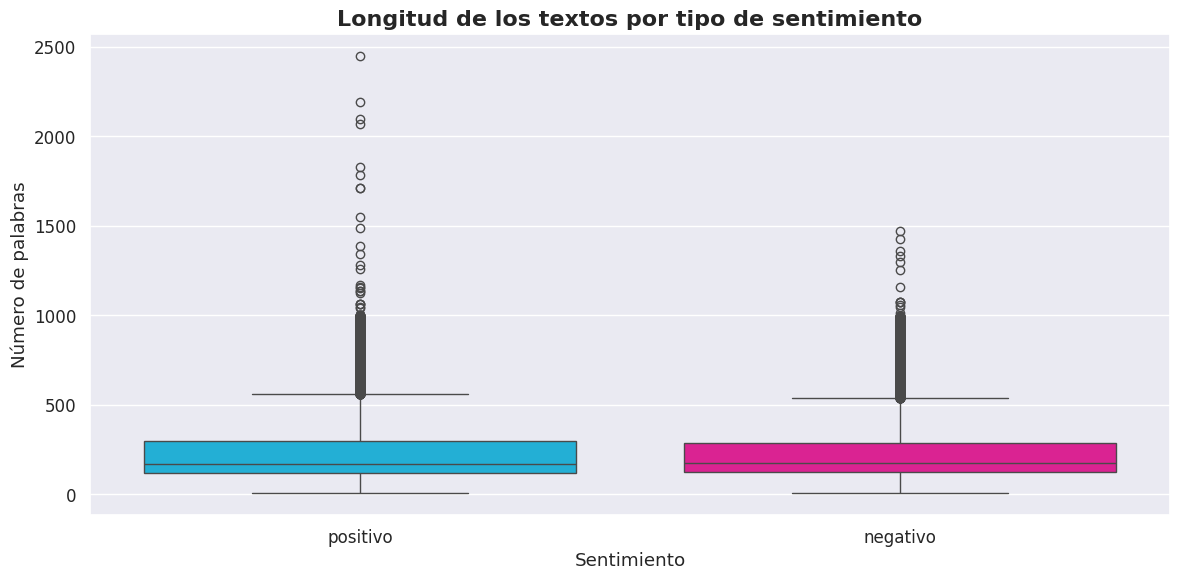

In [33]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [34]:
datos.isnull().sum()

,0
review_es,0
sentimiento,0
n_palabras,0


No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [35]:
def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "desconocido"

In [36]:
datos.shape

(49599, 3)

In [37]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [38]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [39]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1816 filas que no estaban en español


In [40]:
datos = datos_limpios

In [41]:
datos.shape

(47783, 4)

## Verificar la distribución de la columna objetivo (Sentimiento)

In [42]:
datos['sentimiento'].value_counts()

,count
sentimiento,
positivo,23935
negativo,23848


## Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

#### Estandarización a minúsculas

In [ ]:
display(datos)

,review_es,sentimiento,n_palabras,review_es_limpio
0,Uno de los otros críticos ha mencionado que de...,positivo,345,uno de los otros críticos ha mencionado que de...
1,Una pequeña pequeña producción.La técnica de f...,positivo,161,una pequeña pequeña producciónla técnica de fi...
2,Pensé que esta era una manera maravillosa de p...,positivo,173,pensé que esta era una manera maravillosa de p...
3,"Básicamente, hay una familia donde un niño peq...",negativo,137,básicamente hay una familia donde un niño pequ...
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo,237,el amor en el tiempo de petter mattei es una p...
...,...,...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo,170,pensé que esta película hizo un buen trabajo a...
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo,105,mala parcela mal diálogo mala actuación direcc...
49997,Soy católica enseñada en escuelas primarias pa...,negativo,246,soy católica enseñada en escuelas primarias pa...
49998,Voy a tener que estar en desacuerdo con el com...,negativo,232,voy a tener que estar en desacuerdo con el com...


In [ ]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [ ]:
datos['review_es_limpio']

,review_es_limpio
0,uno de los otros críticos ha mencionado que de...
1,una pequeña pequeña producción.la técnica de f...
2,pensé que esta era una manera maravillosa de p...
3,"básicamente, hay una familia donde un niño peq..."
4,"el ""amor en el tiempo"" de petter mattei es una..."
...,...
49995,pensé que esta película hizo un buen trabajo a...
49996,"mala parcela, mal diálogo, mala actuación, dir..."
49997,soy católica enseñada en escuelas primarias pa...
49998,voy a tener que estar en desacuerdo con el com...


#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [ ]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)

In [ ]:
display(datos['review_es_limpio'])

,review_es_limpio
0,uno de los otros críticos ha mencionado que de...
1,una pequeña pequeña producciónla técnica de fi...
2,pensé que esta era una manera maravillosa de p...
3,básicamente hay una familia donde un niño pequ...
4,el amor en el tiempo de petter mattei es una p...
...,...
49995,pensé que esta película hizo un buen trabajo a...
49996,mala parcela mal diálogo mala actuación direcc...
49997,soy católica enseñada en escuelas primarias pa...
49998,voy a tener que estar en desacuerdo con el com...


`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

#### Eliminar espacios múltiples

In [ ]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
display(datos['review_es_limpio'])

,review_es_limpio
0,uno de los otros críticos ha mencionado que de...
1,una pequeña pequeña producción.la técnica de f...
2,pensé que esta era una manera maravillosa de p...
3,"básicamente, hay una familia donde un niño peq..."
4,"el ""amor en el tiempo"" de petter mattei es una..."
...,...
49995,pensé que esta película hizo un buen trabajo a...
49996,"mala parcela, mal diálogo, mala actuación, dir..."
49997,soy católica enseñada en escuelas primarias pa...
49998,voy a tener que estar en desacuerdo con el com...


## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [ ]:
display(datos)

,review_es,sentimiento,n_palabras,review_es_limpio
0,Uno de los otros críticos ha mencionado que de...,positivo,345,uno de los otros críticos ha mencionado que de...
1,Una pequeña pequeña producción.La técnica de f...,positivo,161,una pequeña pequeña producción.la técnica de f...
2,Pensé que esta era una manera maravillosa de p...,positivo,173,pensé que esta era una manera maravillosa de p...
3,"Básicamente, hay una familia donde un niño peq...",negativo,137,"básicamente, hay una familia donde un niño peq..."
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo,237,"el ""amor en el tiempo"" de petter mattei es una..."
...,...,...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo,170,pensé que esta película hizo un buen trabajo a...
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo,105,"mala parcela, mal diálogo, mala actuación, dir..."
49997,Soy católica enseñada en escuelas primarias pa...,negativo,246,soy católica enseñada en escuelas primarias pa...
49998,Voy a tener que estar en desacuerdo con el com...,negativo,232,voy a tener que estar en desacuerdo con el com...


### **Definición de variables de entrada (X) y salida (y)**

In [ ]:
X = datos['review_es_limpio']

In [ ]:
display(X)

,review_es_limpio
0,uno de los otros críticos ha mencionado que de...
1,una pequeña pequeña producción.la técnica de f...
2,pensé que esta era una manera maravillosa de p...
3,"básicamente, hay una familia donde un niño peq..."
4,"el ""amor en el tiempo"" de petter mattei es una..."
...,...
49995,pensé que esta película hizo un buen trabajo a...
49996,"mala parcela, mal diálogo, mala actuación, dir..."
49997,soy católica enseñada en escuelas primarias pa...
49998,voy a tener que estar en desacuerdo con el com...


In [ ]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

In [ ]:
display(y)

,sentimiento
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


### **División de datos en conjuntos de entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [ ]:
stopwords_es = stopwords.words('spanish')

In [ ]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_es,
    ngram_range = (1, 2),
    max_features = 5000,
    min_df = 5,
    max_df = 0.9
)

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [ ]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

In [ ]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2773055 stored elements and shape (34719, 5000)>

### **Transformación del conjunto de prueba**

In [ ]:
X_test_tfidf = vectorizador.transform(X_test)

In [ ]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1181173 stored elements and shape (14880, 5000)>

#### Dimension

In [ ]:
X_train_tfidf.shape

(34719, 5000)

In [ ]:
X_test_tfidf.shape

(14880, 5000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [ ]:
modelo = LogisticRegression(random_state=42)

#### Entrenamiento del modelo

In [ ]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(random_state=42)

#### Predicciones

In [ ]:
y_pred = modelo.predict(X_test_tfidf)

In [ ]:
y_proba = modelo.predict_proba(X_test_tfidf) # Obtiene las probabilidades, esencial para el contrato de la API

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [ ]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.88      0.85      0.87      7448
    positivo       0.86      0.89      0.87      7432

    accuracy                           0.87     14880
   macro avg       0.87      0.87      0.87     14880
weighted avg       0.87      0.87      0.87     14880



## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el BackEnd pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [ ]:
pipeline_final = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words=stopwords_es,
        ngram_range=(1, 2),
        max_features=5000,
        min_df=5,
        max_df=0.9
    )),
    ('clf', LogisticRegression(random_state=42))
])

### **Reentrenar el pipeline con X y Y**

In [ ]:
pipeline_final.fit(X, y)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=5000, min_df=5,
                                 ngram_range=(1, 2),
                                 stop_words=['de', 'la', 'que', 'el', 'en', 'y',
                                             'a', 'los', 'del', 'se', 'las',
                                             'por', 'un', 'para', 'con', 'no',
                                             'una', 'su', 'al', 'lo', 'como',
                                             'más', 'pero', 'sus', 'le', 'ya',
                                             'o', 'este', 'sí', 'porque', ...])),
                ('clf', LogisticRegression(random_state=42))])

### **Serialización**

In [ ]:
joblib.dump(pipeline_final, 'sentiment_model_1.1.joblib')

['sentiment_model_1.1.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [ ]:
# Simulación de predicción
texto_ejemplo = "La interfaz es confusa y me hicieron esperar mucho."

In [ ]:
pred_sentimiento = pipeline_final.predict([texto_ejemplo])

In [ ]:
probabilidades = pipeline_final.predict_proba([texto_ejemplo])

In [ ]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [ ]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.68


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

In [ ]:
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}


**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

In [ ]:
# Arhivo txt, requirements.txt
# Dentro del archivo .txt el siguiente texto:

fastapi
uvicorn
joblib
scikit-learn
nltk
numpy

In [ ]:
# Arhivo py, app.py
# Dentro del archivo .py el siguiente codigo:

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np
import os

# Definición de la app
app = FastAPI(title="Sentiment Analysis API")

# Cargar el modelo

MODEL_PATH = "sentiment_model.joblib" # O "sentiment_model_1.1.joblib"

if not os.path.exists(MODEL_PATH):
    raise Exception(f"No se encontró el archivo del modelo en: {MODEL_PATH}")

modelo = joblib.load(MODEL_PATH)

class SentimentRequest(BaseModel):
    text: str

class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):
    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento."
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

In [ ]:
# Arhivo ipynb, Modelo_hackathon.ipynb
# El archivo .ipynb crea el archivo (sentiment_model.joblib)
# Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 2. Encender el servidor: uvicorn app:app --reload